# Marlim3 - Tutorials in Python

# Black-box Multiphase Flow Correlations

In this notebook, we use the [**Marlim3**](https://github.com/petrobras/marlim3) multiphase flow simulator to explore the concept of **black-box correlations** for two-phase flow in pipes. We compare several classical correlations, grouped by category, and analyze their impact on pressure, temperature, holdup, and pressure drop components (friction and hydrostatic). The simulations are run in **steady-state** regime.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import marlim3
import copy

## Introduction

When modeling multiphase flow in pipes, there are two broad approaches available in [**Marlim3**](https://github.com/petrobras/marlim3):

1. **Drift-flux model** (`initialConfig.driftModel = true`): a mechanistic model that solves conservation equations with closure relations for the drift velocity and distribution parameter. This is the default and recommended approach, and is the only one available for transient simulations.

2. **Black-box correlations** (`initialConfig.driftModel = false`): empirical correlations that compute pressure gradients (friction, gravity, acceleration) and liquid holdup based on experimental data. These are available **only for steady-state** simulations and are selected per duct via `productionDucts.mr2Correlation`.

In this tutorial we focus on the **black-box correlations**, which have historical importance and are still widely used in practice. [**Marlim3**](https://github.com/petrobras/marlim3) implements 16 correlations, numbered from 0 to 15.

## Correlation categories

The correlations can be grouped into three categories:

- **Category I — Homogeneous (no-slip)**: assumes the flow is homogeneous, disregarding slip between phases and their spatial configurations (flow patterns). A single friction factor correlation is used, independent of flow pattern. These are highly simplified approaches, generally valid only for the fields where they were developed, and maintained here mostly for historical reasons.

- **Category II — Slip with global holdup**: considers the slip between phases and computes the holdup through correlations that are applied to all flow patterns. These correlations improve over Category I by accounting for the velocity difference between gas and liquid, but do not distinguish between different flow regimes.

- **Category III — Slip with flow pattern recognition**: considers both the slip and the flow pattern. For each type of flow arrangement, an appropriate correlation is used. Holdup correlations are also employed. These are, in principle, the most recommended.

All correlations compute three components of the pressure gradient: **friction**, **gravity** (hydrostatic) and **acceleration**. The total gradient is given by $dp/dz = (dp_{fric} + dp_{grav}) / (1 - E_k)$, where $E_k$ is the dimensionless kinetic energy (acceleration) parameter. When $E_k > 0.95$, the flow is flagged as critical.

## Available correlations

The following table summarizes all 16 correlations available in [**Marlim3**](https://github.com/petrobras/marlim3):

| ID | Correlation | Category | Recommended geometry |
|:---:|:---|:---:|:---|
| 0 | Poettmann & Carpenter | I | Vertical |
| 1 | Baxendell & Thomas | I | Vertical |
| 2 | Fancher & Brown | I | Vertical |
| 3 | Hagedorn & Brown | II | Vertical |
| 4 | Duns & Ros | III | Vertical |
| 5 | Orkiszewski | III | Vertical |
| 6 | Beggs & Brill | III | Any angle |
| 7 | Mukherjee & Brill | III | Any angle |
| 8 | Aziz, Govier & Fogarasi | III | Vertical |
| 9 | Gray | II | Vertical (gas wells) |
| 10 | Oliemans | II | Horizontal |
| 11 | Dukler | II | Horizontal |
| 12 | Beggs & Brill with Palmer correction | III | Any angle |
| 13 | Dukler, Eaton & Flanigan | II | Horizontal |
| 14 | Dukler & Minami I | II | Horizontal |
| 15 | Dukler & Minami II | II | Horizontal |

## Correlation descriptions

### Category I — Homogeneous (no-slip)

- **Poettmann & Carpenter** (ID 0) [[1](#ref1), [2](#ref2), [3](#ref3)]: developed for vertical upward flow from real well data. Recommended for tubing sizes of 2⅜", 2⅞" or 3½", viscosities below 5 cP, gas-liquid ratios below 1500 scf/bbl (267 m³/m³) and flow rates above 400 bpd (64 m³/d). Only valid for bubble or slug flow patterns.

- **Baxendell & Thomas** (ID 1) [[2](#ref2), [4](#ref4)]: similar to Poettmann & Carpenter, developed from field data at La Paz, Venezuela. Covered a wider range of liquid flow rates (20 to 800 m³/d), but a much narrower range of gas-liquid ratios (10 to 20 m³/m³).

- **Fancher & Brown** (ID 2) [[1](#ref1), [2](#ref2), [5](#ref5)]: also for vertical upward flow, but developed from experimental data using air-water flow in a plastic-lined 8000 ft test well. Considered one of the best for 2⅜" tubing, extensible with some confidence to 2⅞". More suitable for liquid flow rates below 400 bbl/d (64 m³/d) and gas-liquid ratios below 5000 scf/bbl (890 m³/m³).

### Category II — Slip with global holdup

- **Hagedorn & Brown** (ID 3) [[1](#ref1), [2](#ref2), [6](#ref6), [7](#ref7)]: one of the most widely used correlations for vertical upward flow. Developed in a 1500 ft experimental well with oil and water flowing with air in 1", 1¼" and 1½" pipes. The holdup is a purely correlational parameter (not directly measured, but obtained indirectly). Should be used only for bubble or slug flow. Note: at low gas fractions, the implementation switches to the mechanistic Griffith-Wallis bubble flow model.

- **Gray** (ID 9) [[21](#ref21)]: developed for **vertical gas wells** with liquid production. Works with the concept of pseudo-roughness and has its own holdup correlation. Adopted by API in standards and programs for SSCSV sizing.

- **Oliemans** (ID 10) [[20](#ref20)]: initially intended for horizontal gas-condensate lines. Uses Eaton's holdup as baseline, then applies its own slip correction by redefining the effective diameter, density and Reynolds number using a slip parameter $\beta_L = H_L - \lambda$. Not widely used.

- **Dukler** (ID 11) [[1](#ref1), [10](#ref10), [11](#ref11), [12](#ref12)]: designed for horizontal flow, developed from laboratory and field databases. According to Brown, it is the most widely used for a wide variety of conditions. Originally recommended with Hughmark's holdup, but for holdups below 0.2 Eaton's correlation is more adequate. Suitable for any diameter, with slightly better results for larger pipes. Appears to perform well regardless of viscosity.

- **Dukler, Eaton & Flanigan** (ID 13) [[1](#ref1), [10](#ref10), [11](#ref11)]: Dukler's correlation with Eaton's holdup and Flanigan's approach for inclined flow.

- **Dukler & Minami I** (ID 14) [[1](#ref1), [12](#ref12)]: Dukler's correlation with Minami's first holdup modification.

- **Dukler & Minami II** (ID 15) [[1](#ref1), [12](#ref12)]: Dukler's correlation with Minami's second holdup modification.

### Category III — Slip with flow pattern recognition

- **Duns & Ros** (ID 4) [[1](#ref1), [2](#ref2)]: developed for vertical upward flow through extensive experimental work with field data adjustments. Brown considers it a good correlation for all ranges of flow rates, tubing diameters and fluids. Restricted to bubble, slug or mist flow patterns.

- **Orkiszewski** (ID 5) [[1](#ref1), [8](#ref8)]: for vertical upward flow, built as an extension of Griffith & Wallis for bubble flow and Duns & Ros for mist flow. Worked with field data for heavy oils. Recommended for bubble, slug or mist flow. Some caution is needed as discontinuities have been detected [[9](#ref9)].

- **Beggs & Brill** (ID 6) [[1](#ref1), [13](#ref13)]: general-purpose correlation applicable to both upward and downward flow at any inclination angle. Developed in the laboratory with water and air in acrylic pipes of 90 ft length and 1" and 1½" diameter, taking flow patterns into account. When no specific information is available, this should be the default choice in the case of black-box correlations. Some discontinuities have been reported [[9](#ref9)].

- **Mukherjee & Brill** (ID 7) [[16](#ref16), [17](#ref17), [18](#ref18)]: another general-purpose correlation applicable at any inclination angle. Developed in the laboratory with a 1½" ID steel pipe (~10 m test section) using kerosene or lubricating oil with air. Compared with North Sea (wells) and Alaska (lines) field data — outperformed Beggs & Brill in the North Sea case, while Beggs & Brill was better for Alaska.

- **Aziz, Govier & Fogarasi** (ID 8) [[2](#ref2), [19](#ref19)]: mechanistic-based, taking flow patterns into account, for vertical upward flow. Developed their own correlation for bubble and slug flow; adopted Duns & Ros for mist. The authors conclude that their correlation has the same accuracy as Orkiszewski's.

- **Beggs & Brill with Palmer correction** (ID 12) [[1](#ref1), [13](#ref13), [14](#ref14)]: the Beggs & Brill correlation with two constant correction factors for holdup proposed by Palmer — one for upward flow and one for downward flow. Palmer's study was limited to inclinations between -6° and +8°. Gould and Ramsey [[15](#ref15)] concluded that this correlation fitted well with real data from 15" gas lines in the Gulf of Mexico.

## How to select a correlation

The choice of the most appropriate correlation follows an empirical process, where calculated results are compared against measurements from wells and lines. In the absence of measured pressure profiles, the descriptions above can help guide the choice.

In [**Marlim3**](https://github.com/petrobras/marlim3), two parameters control the correlation selection:

1. `initialConfig['driftModel'] = False` — disables the drift-flux model and enables the black-box correlations.
2. `productionDucts[i]['mr2Correlation'] = N` — selects the correlation number $N$ (0 to 15) for duct $i$.

Note that different ducts can use different correlations, which can be useful when the flow geometry changes (e.g., vertical well vs. horizontal flowline).

## Building the base case

    "We will build a simplified case with a single vertical pipe to compare the correlations. This setup is inspired by the tutorial `1-horizontal_vertical_comparison.ipynb`."

In [2]:
base_case = marlim3.Branch()

### Production fluid

We define a [*black oil*](https://wiki.whitson.com/bopvt/bot/) production fluid:

In [3]:
fluid = {
    "id": 0,
    "api": 20,
    "rgo": 100, #Sm3/Sm3
    "gasDensity": 0.7,
    "bsw": 0.0,
}

base_case.productionFluids = [fluid]

### Pipe material

In [4]:
steel = {
    "id": 0,
    "type": 0, #solid
    "conductivity": 58, #W/m.K
    "specificHeat": 480, #J/kg.K
    "rho": 7850, #kg/m3
}

base_case.material = [steel]

### Cross-section

A single cross-section with one steel layer ($1$" thickness), $10$" inner diameter and $0.183$ mm of absolute roughness:

In [5]:
layer = {
    "materialId": 0,
    "layerMeasurementType": "thickness",
    "thickness": 0.0254, #m
}

section = {
    "id": 0,
    "innerDiameter": 10*0.0254, #m
    "roughness": 0.183e-3, #m
    "layers": [layer]
}

base_case.crossSection = [section]

### Production duct

A single vertical pipe with $2500$ m length, divided into $20$ cells. The external environment is the atmosphere:

In [6]:
ncel = 20
total_length = 2500 #m

line = {
    "numCells": ncel,
    "length": total_length/ncel #m
}

env_cond = {
    "measuredPositions": [0, 1],
    "externalTemp": [80, 20], #degC
    "externalVel": [0.5, 0.5], #m/s
}

duct = {
    "id": 0,
    "crossSectionId": 0,
    "externalEnvironment": 2, #atmosphere
    "angle": np.pi/2, #rad (vertical)
    "discretization": [line],
    "initialConditions": env_cond
}

base_case.productionDucts = [duct]

In [7]:
base_case.plot_geometry();

### Boundary conditions

Upstream: fixed liquid flow rate at the pipe inlet. Downstream: fixed separator pressure.

In [8]:
up_bc = {
    "id": 0,
    "prodFluidId": 0,
    "measuredLength": 0.1, #m
    "time": [0], #s
    "liquidFlowRate": [1500], #sm3/d
    "temperature": [80] #degC
}

base_case.liquidSource = [up_bc]

down_bc = {
    "time": [0], #s
    "pressure": [20], #kgf/cm2
}

base_case.separator = down_bc

### Output variables

In [9]:
out_vars_list = ["pressure",
                   "temperature",
                   "holdup",
                   "frictionPressure",
                   "hydrostaticPressure"]

output_vars = {"time": [0]} | {var: True for var in out_vars_list}

base_case.productionProfile = output_vars

### Enabling black-box correlations

We disable the drift-flux model so that the black-box correlations are used instead:

In [10]:
base_case.initialConfig['driftModel'] = False

We also define a dictionary mapping correlation IDs to names, which will be used as labels in our comparisons:

In [11]:
corr_names = {
    0: 'Poettmann-Carpenter',
    1: 'Baxendell-Thomas',
    2: 'Fancher-Brown',
    3: 'Hagedorn-Brown',
    4: 'Duns-Ros',
    5: 'Orkiszewski',
    6: 'Beggs-Brill',
    7: 'Mukherjee-Brill',
    8: 'Aziz-Govier-Fogarasi',
    9: 'Gray',
    10: 'Oliemans',
    11: 'Dukler',
    12: 'Beggs-Brill-Palmer',
    13: 'Dukler-Eaton-Flanigan',
    14: 'Dukler-Minami I',
    15: 'Dukler-Minami II',
}

We define a helper function that runs a set of correlations on a given base case and returns a `Cenarios` object for easy comparison. The **drift-flux model** result is always included as a reference:

In [12]:
def compare_correlations(case, correlations_ids):
    """Run simulations for each correlation ID and return a Cenarios object.
    Includes drift-flux model as reference."""
    # Drift-flux reference
    drift_case = copy.deepcopy(case)
    drift_case.initialConfig['driftModel'] = True
    drift_case.simulate()
    cases = {'Drift-flux (ref.)': drift_case}
    # Black-box correlations
    for corr_id in correlations_ids:
        corr_case = copy.deepcopy(case)
        for branch in corr_case.productionDucts:
            branch['mr2Correlation'] = corr_id
        corr_case.simulate()
        cases[corr_names[corr_id]] = corr_case
    return marlim3.Scenarios(cases)

## Category I — Homogeneous (no-slip) correlations

Category I correlations assume homogeneous flow, disregarding the slip between phases. They use a single friction factor correlation regardless of the flow pattern. These are the simplest approaches: **Poettmann & Carpenter** (0), **Baxendell & Thomas** (1) and **Fancher & Brown** (2).

Let's compare them on our vertical base case:

In [13]:
cat1_scenarios = compare_correlations(base_case, [0, 1, 2])

*******************************************************************************
                                  UFA!!!!!!!!                                  
O sucesso nao e uma linha reta, e um jogo de resistencia, e cada tropeco e apenas um degrau a mais para a vitoria!
                                    Mario Pascal do Insta                               
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                                  UFA!!!!!!!!                                  
                   Infeliz e o espirito ansioso pelo futuro.                    
                              Seneca do Mindfulness                                     
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
    

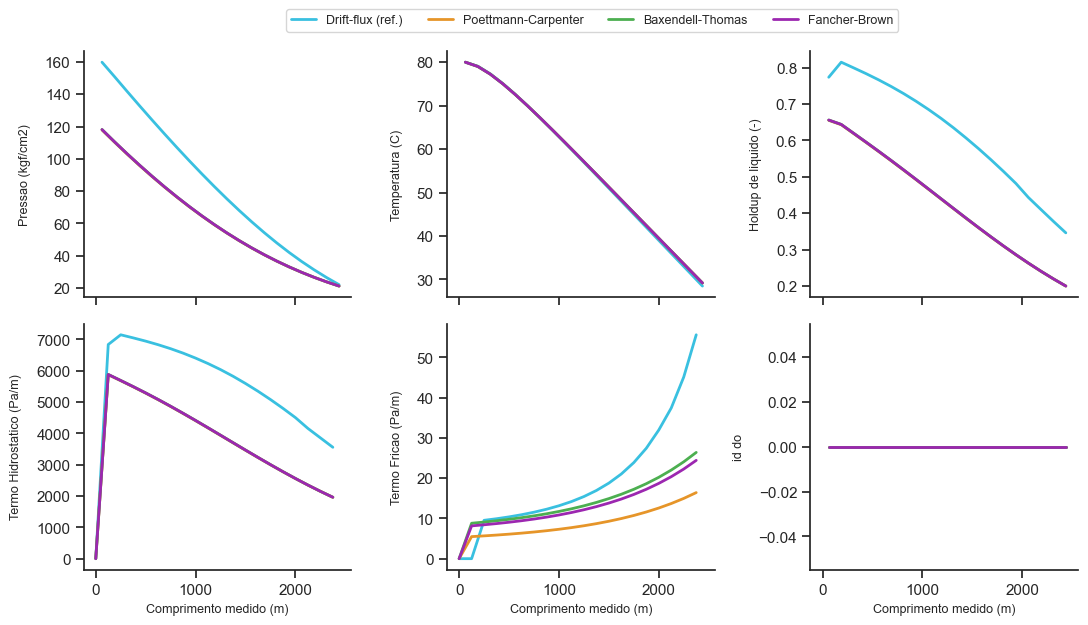

In [14]:
cat1_scenarios.plot_profiles();

All three Category I correlations produce **identical profiles** for pressure, temperature, holdup and the hydrostatic term. The only difference between them is in the **friction term**. This is expected: since these correlations assume homogeneous (no-slip) flow, they all use the same no-slip holdup (equal to the input liquid fraction) and the same mixture density for the hydrostatic calculation. What distinguishes them is solely the empirical friction factor correlation — each was fitted to a different experimental dataset, hence the small differences in the friction pressure gradient.

Their simplicity makes them fast but less accurate for conditions outside their original calibration range. Because they ignore slip, they tend to underestimate the holdup (and therefore the hydrostatic pressure drop) in vertical flow.

## Category II — Slip with global holdup correlations

Category II correlations account for the slip between gas and liquid phases. They compute the liquid holdup using correlations that are applied uniformly across all flow patterns. This is a significant improvement over Category I, as slip can have a major effect on the pressure gradient, especially in vertical flow.

We will compare **Hagedorn & Brown** (3), which is one of the most widely used correlations for vertical flow, and **Dukler** (11), which was designed for horizontal flow. We also include **Gray** (9) and **Oliemans** (10):

In [15]:
cat2_scenarios = compare_correlations(base_case, [3, 9, 10, 11])

*******************************************************************************
                                  UFA!!!!!!!!                                  
                 Nao importa o quanto voce va devagar, desde que nao pare                
                             Confucio vendo a simulacao emperrar                       
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                                  UFA!!!!!!!!                                  
             Paciencia, nove mulheres nao conseguem gerar uma crianca em um mes. 
                                      Tiao do Linkedin                                  
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                             

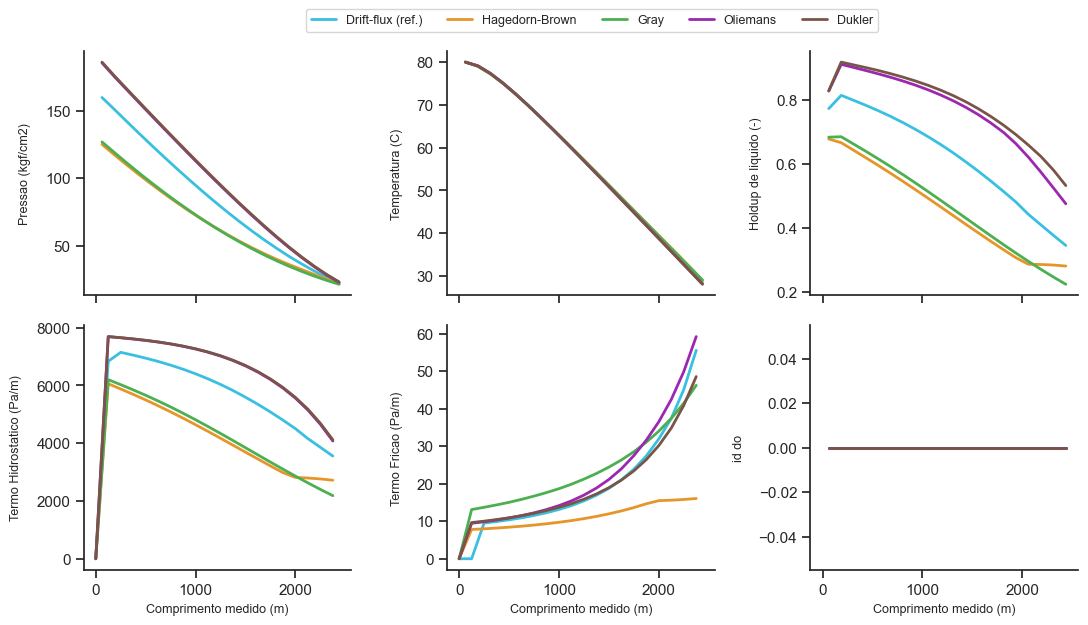

In [16]:
cat2_scenarios.plot_profiles();

Here we can see a much larger spread in the results compared to Category I, because each correlation now computes its own holdup (accounting for slip). Two groups emerge:

- **Hagedorn & Brown** and **Gray** predict similar (lower) holdups. Both were developed for vertical wells where the gas phase tends to rise faster than the liquid, and their holdup models reflect that regime.

- **Oliemans** and **Dukler** predict similar (higher) holdups. Both were designed for horizontal flow, where the slip mechanism is different — in a vertical pipe, their holdup models tend to overestimate the liquid fraction.Since the hydrostatic pressure gradient is directly proportional to holdup, the Oliemans/Dukler group predicts a larger total pressure drop in this vertical configuration. This clearly illustrates why the choice of correlation should match the geometry of the problem: using a horizontal-flow correlation in a vertical pipe can lead to significant overprediction of the hydrostatic term.


## Category III — Slip with flow pattern recognition

Category III correlations are the most sophisticated of the black-box approaches. They identify the flow pattern (bubble, slug, annular/mist, etc.) and apply specific correlations for each regime. This is important because the physics of pressure drop and holdup vary dramatically between flow patterns.

To highlight the differences between these correlations, we increase the gas-oil ratio to $500$ Sm³/Sm³. This raises the gas superficial velocity, amplifying the differences in holdup and pressure gradient predictions.

We compare **Duns & Ros** (4), **Orkiszewski** (5), **Beggs & Brill** (6), **Mukherjee & Brill** (7), **Aziz, Govier & Fogarasi** (8) and **Beggs & Brill with Palmer correction** (12):

In [17]:
cat3_case = copy.deepcopy(base_case)

cat3_case.productionFluids[0]['rgo'] = 500 #Sm3/Sm3

cat3_scenarios = compare_correlations(cat3_case, [4, 5, 6, 7, 8, 12])


*******************************************************************************
                                  UFA!!!!!!!!                                  
                        Quem vive de navegar, o vento e quem lhe comanda                
                          Seu Pereira na feira de artesanatos numericos                 
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                                  UFA!!!!!!!!                                  
                   Infeliz e o espirito ansioso pelo futuro.                    
                              Seneca do Mindfulness                                     
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                              

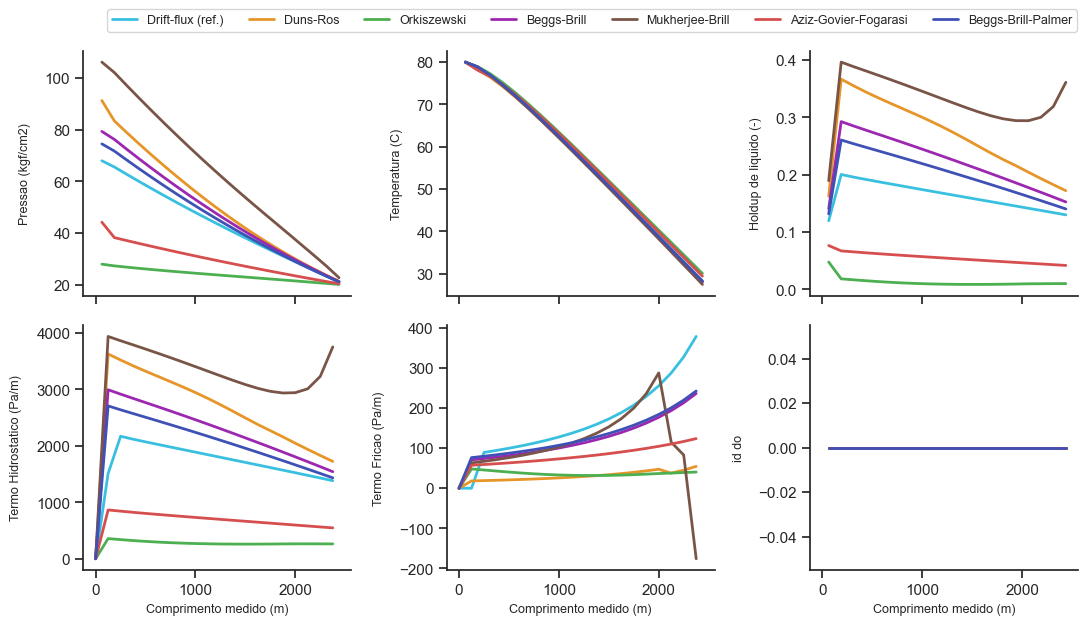

In [18]:
cat3_scenarios.plot_profiles();

With the higher RGO ($500$ Sm³/Sm³), the increased gas superficial velocity amplifies the differences in holdup and pressure gradient predictions between the correlations. Each Category III correlation uses its own internal flow pattern map to select the appropriate sub-correlation for computing holdup and friction — this leads to visible differences in the output profiles even though the flow pattern itself is not directly reported.

The **Beggs & Brill** correlation is the most general-purpose of the group, being applicable at any inclination angle. The **Palmer correction** (ID 12) modifies the holdup prediction of Beggs & Brill with constant factors for upward and downward flow, which can be seen as a slight shift in the holdup and hydrostatic profiles.

The spread in predicted pressure and holdup between these correlations illustrates the key source of uncertainty in multiphase flow modeling and why the choice of correlation matters.

## Cross-category comparison

To visualize the impact of the correlation category, let's compare one representative from each:

- **Category I**: Poettmann & Carpenter (0) — homogeneous, no slip
- **Category II**: Hagedorn & Brown (3) — slip with global holdup
- **Category III**: Beggs & Brill (6) — slip with flow pattern recognition

In [19]:
category_scenarios = compare_correlations(base_case, [0, 3, 6])

*******************************************************************************
                                  UFA!!!!!!!!                                  
                  A necessidade e a mae da inovacao, mas a paciencia e o pai    
                                      Marcao da Oficina                                 
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                                  UFA!!!!!!!!                                  
                  Uma jornada de mil quilometros comeï¿½a com um unico passo                
    Lao-Tse tomando coragem para simular um caso de parafinacao em dutos de producao    
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                          

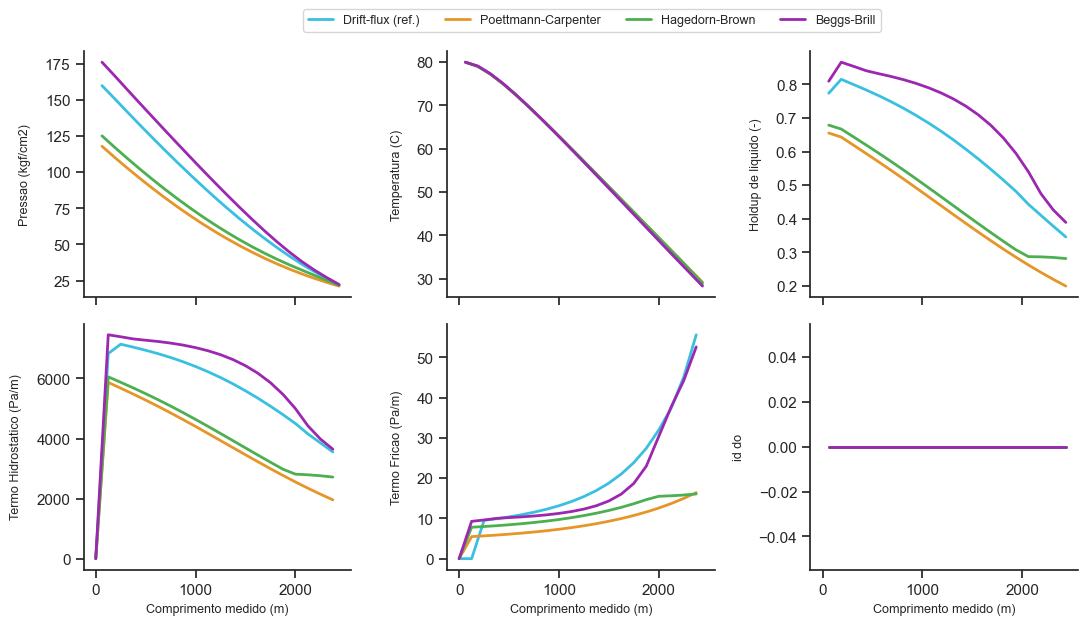

In [20]:
category_scenarios.plot_profiles();

This comparison highlights the fundamental differences between the three categories:

- **Pressure**: the total pressure drop can vary significantly depending on whether slip is accounted for. Category I (no-slip) tends to underestimate the holdup in vertical flow, which affects the hydrostatic component.
- **Holdup**: Categories II and III predict the holdup through correlations that account for slip, typically resulting in higher holdup values compared to the no-slip assumption of Category I.

In general, Category III correlations are the most recommended when measured data is not available for calibration. Among them, **Beggs & Brill** is the most versatile due to its applicability at any inclination angle.

## Horizontal case comparison

Some correlations were specifically developed for horizontal flow (Dukler, Oliemans), while others are general-purpose (Beggs & Brill, Mukherjee & Brill). Let's create a horizontal base case and compare the relevant correlations.

The main physical difference is that in horizontal flow there is **no hydrostatic pressure drop**, and the dominant mechanism becomes friction. Also, flow patterns like **stratified flow** can appear, which do not exist in vertical pipes.

**A note on convergence**: horizontal cases can be harder to converge numerically. The steady-state solver estimates the inlet pressure using hydrostatic contributions, which vanish for horizontal pipes (`sin(0) = 0`). To help convergence, we use a higher separator pressure ($10$ kgf/cm²) and a moderate RGO — this avoids extreme void fractions at the outlet that destabilize the friction correlations.

In [21]:
horizontal_base_case = copy.deepcopy(base_case)
horizontal_base_case.productionDucts[0]['angle'] = 0 #rad (horizontal)
horizontal_base_case.separator = {"time": [0], "pressure": [10]} #kgf/cm2

In [22]:
horizontal_base_case.plot_geometry();

Now let's compare the correlations that are commonly used for horizontal flow — the Dukler family (IDs 11, 13, 14, 15), Oliemans (10), Beggs & Brill (6), Mukherjee & Brill (7) and Beggs & Brill with Palmer (12):

In [23]:
horizontal_scenarios = compare_correlations(horizontal_base_case, [6, 7, 10, 11, 12, 13, 14, 15])

*******************************************************************************
                                  UFA!!!!!!!!                                  
    Uma vez me perguntaram o que achava da passagem do tempo, e eu disse: sou contra    
                        Luis Fernando Verissimo das Simulacoes Permanentes              
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                                  UFA!!!!!!!!                                  
      So nos curamos de um sofrimento depois de o haver suportado ate o fim.    
                                Marcel Proust no CrossFit                               
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

*******************************************************************************
                              

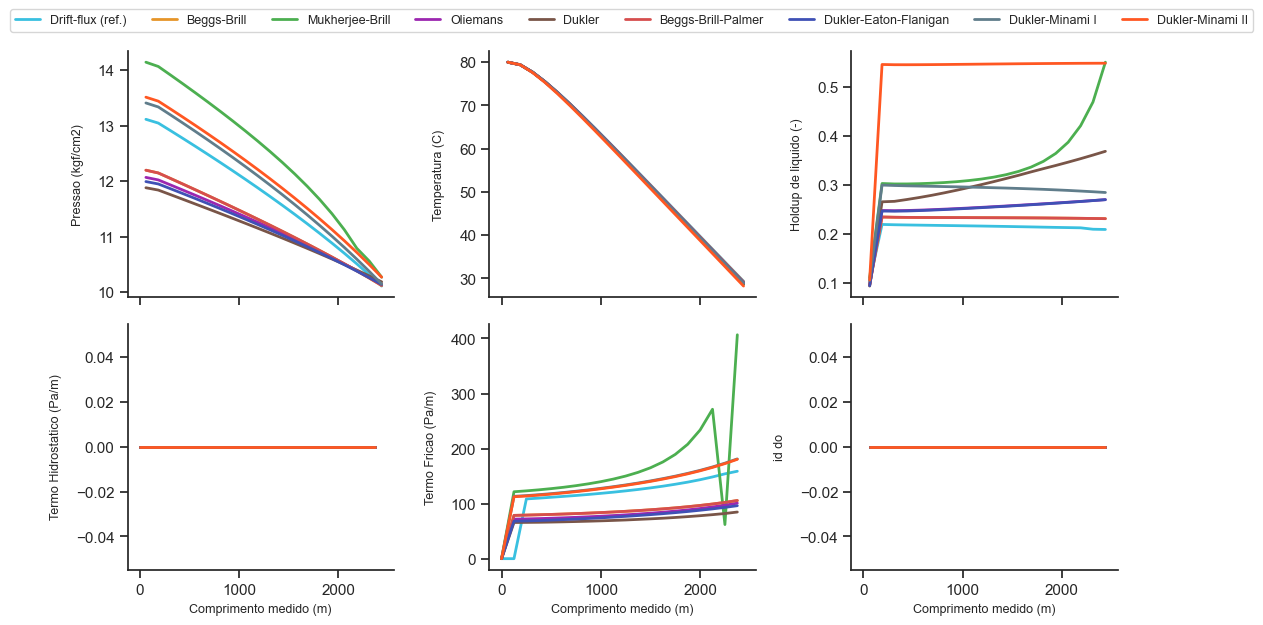

In [24]:
horizontal_scenarios.plot_profiles();

In the horizontal case, the **hydrostatic term is zero** (as expected for a horizontal pipe), and the pressure drop is entirely due to friction. The differences between correlations now come from how they estimate the friction factor and, importantly, the holdup — which affects the mixture density and velocity used in the friction calculation.

**A note on friction models**: the Dukler family (IDs 11, 13, 14, 15) uses a **Blasius smooth-pipe** formula with a two-phase correction factor (dependent on liquid fraction), while most other correlations use the **Moody/Colebrook-White** friction factor which accounts for pipe roughness directly. For non-horizontal flow, the Dukler family computes the gravity gradient using **Flanigan's correlation** — a factor $\phi(v_{sg})$ that reduces the hydrostatic contribution as gas velocity increases.

Looking at the four Dukler variants (IDs 11, 13, 14, 15), we can identify two distinct subgroups:

- **Dukler (11) and Dukler-Eaton-Flanigan (13)** produce similar friction profiles. Both use the **Dukler slip density** $\rho_m = \rho_L \lambda^2/H_L + \rho_G(1-\lambda)^2/(1-H_L)$ in the friction calculation, which accounts for the velocity difference between phases. Their holdup models differ (Dukler's iterative charts vs. Eaton's empirical formula), but both were calibrated on horizontal pipe data from the 1960s and tend to predict similar holdups.

- **Dukler-Minami I (14) and Dukler-Minami II (15)** predict higher friction. This is because they use the **no-slip (volumetric-average) density** $\rho_m = \rho_L\lambda + \rho_G(1-\lambda)$ instead of the slip density. Since typically $H_L > \lambda$ (liquid accumulates due to slip), the slip density is lower than the no-slip density, so the Minami variants compute a larger $\rho_m$ and therefore a higher friction gradient.

Regarding holdup, the differences arise from the base holdup correlations themselves. Note that the Minami variants apply a **Beggs & Brill inclination correction** $\psi(\theta)$ when the pipe is non-horizontal (including flow-pattern determination), but for horizontal flow $\psi(0)=1$ and the correction has no effect:

- **Minami II** predicts significantly higher holdup than all others. Its exponential model (Eaton-based) is designed for general two-phase flow and tends to produce much larger liquid fractions in this regime.
- **Minami I** shows an interesting crossover: it predicts higher holdup than Dukler near the pipe inlet (where pressure is higher and the gas fraction is lower), but lower holdup near the outlet (where gas expansion increases the void fraction). This is because its polynomial fit was designed for wet-gas (low-liquid) flows and has a different functional shape that responds differently to local conditions along the pipe.
- **Dukler** and **Eaton** predict similar, lower holdups — both were calibrated on horizontal pipe data from the 1960s.

**Beggs & Brill** and **Mukherjee & Brill** are general-purpose correlations that can handle horizontal flow, but they were not specifically calibrated for it. In practice, when dealing with horizontal or near-horizontal pipelines, the Dukler family or Beggs & Brill are common choices.

## Sensitivity to flow rate

The agreement (or disagreement) between correlations can vary significantly depending on operating conditions. Let's explore how a few representative correlations behave across a range of liquid flow rates for the vertical case.

We will compute the bottom-hole pressure (inlet pressure) for each correlation at several flow rates and plot the results:

In [25]:
%%time

selected_corrs = [0, 3, 6, 4, 5]
flow_rates = np.linspace(500, 6000, 12)

flow_rate_results = {corr_id: [] for corr_id in selected_corrs}
drift_results = []

for flow_rate in flow_rates:
    # Drift-flux reference
    drift_case = copy.deepcopy(base_case)
    drift_case.initialConfig['driftModel'] = True
    drift_case.liquidSource[0]['liquidFlowRate'] = [flow_rate]
    drift_case.initialConfig['classicOutput'] = False
    try:
        drift_case.simulate()
        drift_results.append(drift_case.results['productionProfile'].iloc[:,2][0,0])
    except Exception:
        drift_results.append(np.nan)

    # Black-box correlations
    for corr_id in selected_corrs:
        case = copy.deepcopy(base_case)
        case.productionDucts[0]['mr2Correlation'] = corr_id
        case.liquidSource[0]['liquidFlowRate'] = [flow_rate]
        case.initialConfig['classicOutput'] = False
        try:
            case.simulate()
            inlet_pressure = case.results['productionProfile'].iloc[:,2][0,0]
        except Exception:
            inlet_pressure = np.nan
        flow_rate_results[corr_id].append(inlet_pressure)









































































CPU times: total: 1.45 s
Wall time: 2min 47s


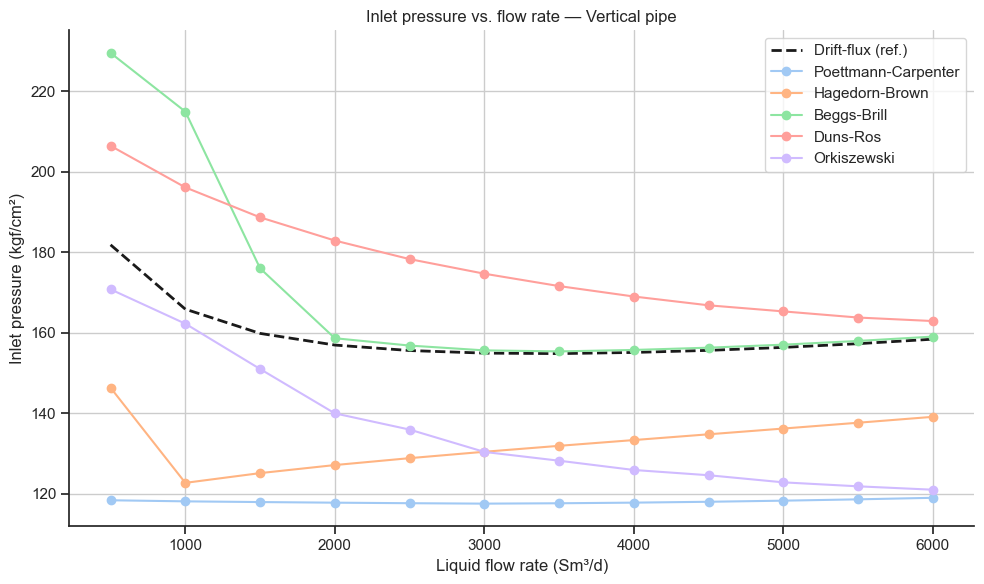

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(flow_rates, drift_results, 'k--', linewidth=2, label='Drift-flux (ref.)')

for corr_id in selected_corrs:
    plt.plot(flow_rates, flow_rate_results[corr_id], marker='o', label=corr_names[corr_id])

plt.xlabel('Liquid flow rate (Sm³/d)')
plt.ylabel('Inlet pressure (kgf/cm²)')
plt.title('Inlet pressure vs. flow rate — Vertical pipe')
plt.legend()

plt.grid()
plt.tight_layout()

This plot reveals how the correlations diverge at different flow rate regimes. At very low flow rates, the differences are typically larger because the holdup prediction has a stronger impact on the hydrostatic pressure gradient. At higher flow rates, friction becomes more dominant and the correlations tend to converge somewhat.

This analysis is analogous to constructing a **TPR (Tubing Performance Relationship)** curve for each correlation — a fundamental tool in well performance analysis (see the `2-nodal_analysis.ipynb` tutorial for more details on TPR curves).

## Drift-flux model vs. black-box correlations

Throughout the plots above, the **drift-flux model** result is included as a reference (`Drift-flux (ref.)`). This is the default mechanistic approach in [**Marlim3**](https://github.com/petrobras/marlim3), which solves conservation equations with physical closure relations rather than relying on empirical fits.

In practice:
- Use the **drift-flux model** for transient simulations and when a mechanistic approach is preferred.
- Use **black-box correlations** for quick steady-state checks, for historical comparison with legacy tools, or when calibrating against field data from wells where a specific correlation is known to perform well.

## Try it yourself!

**1.** Vary the gas-oil ratio (RGO) of the production fluid (e.g., from $50$ to $500$ Sm³/Sm³) and compare how the correlations respond. Which correlations are more sensitive to changes in RGO? Use the `Scenarios` class to organize the comparisons.

**2.** Repeat the cross-category comparison (Category I vs II vs III) for the horizontal case. Are the differences between categories as pronounced as in the vertical case? Why?

**3.** Try different pipe diameters (e.g., $5$" to $20$") and observe which correlations are more sensitive to diameter changes. Relate your observations to the applicability ranges described in the introduction.

**4.** For horizontal flow, compare the four Dukler variants (IDs 11, 13, 14, 15) at different flow rates. Since they share the same friction model but differ in holdup prediction, the differences will isolate the effect of the holdup correlation.

**5.** Add a non-zero BSW (e.g., $0.3$) to the production fluid and re-run the Category III comparisons. Do some correlations handle water-cut better than others?

## References

<a id="ref1"></a>
[1] BROWN, K.E., "The Technology of Artificial Lift Methods - volume 1", PPC Books, Tulsa, OK, USA, 1977.

<a id="ref2"></a>
[2] SZILAS, A.P., "Production and Transport of Oil and Gas - Part A: Flow Mechanics and Production", 2nd Edition, Elsevier, Budapest, Hungary, 1985.

<a id="ref3"></a>
[3] POETTMANN, F.H. and CARPENTER, P.G., "The Multiphase Flow of Gas, Oil, and Water Through Vertical Flow Strings with Application to the Design of Gas-lift Installations", Drilling and Production Practice, API, 1952, pp. 257-317.

<a id="ref4"></a>
[4] BAXENDELL, P.B. and THOMAS, R., "The Calculation of Pressure Gradients in High-Rate Flowing Wells", JPT, October 1961, pp. 1023-1028.

<a id="ref5"></a>
[5] FANCHER, G.H. and BROWN, K.E., "Prediction of Pressure Gradients for Multiphase Flow in Tubing", SPE Journal, March 1963, pp. 59-69.

<a id="ref6"></a>
[6] HAGEDORN, A.R. and BROWN, K.E., "Experimental Study of Pressure Gradients Occurring During Continuous Two-Phase Flow in Small-Diameter Vertical Conduits", JPT, April 1965, pp. 475-484.

<a id="ref7"></a>
[7] GRIFFITH, P. and WALLIS, G.B., "Two-Phase Slug Flow", Journal of Heat Transfer, Transactions of the ASME, August 1961, pp. 307-320.

<a id="ref8"></a>
[8] ORKISZEWSKI, J., "Predicting Two-Phase Pressure Drops in Vertical Pipe", JPT, June 1967, pp. 829-838.

<a id="ref9"></a>
[9] AZIZ, K. and PETALAS, N., "Brief: New PC-Based Software for Multiphase-Flow Calculations", JPT, June 1995, pp. 494-495.

<a id="ref10"></a>
[10] EATON, B.A. et al., "The Prediction of Flow Patterns, Liquid Holdup and Pressure Losses Occurring During Continuous Two-Phase Flow in Horizontal Pipelines", JPT, June 1967, pp. 815-828.

<a id="ref11"></a>
[11] FLANIGAN, O., "Effect of Uphill Flow on Pressure Drop in Design of Two-Phase Gathering Systems", Oil and Gas Journal, March 10, 1958, pp. 315-328.

<a id="ref12"></a>
[12] MINAMI, K., "Liquid Holdup in Wet-Gas Pipelines", M.Sc. Thesis, The University of Tulsa, Tulsa, 1983.

<a id="ref13"></a>
[13] BEGGS, H.D. and BRILL, J.P., "A Study of Two-Phase Flow in Inclined Pipes", JPT, May 1973, pp. 607-617.

<a id="ref14"></a>
[14] PALMER, C.M., "Evaluation of Inclined Pipe Two-Phase Liquid Holdup Correlations Using Experimental Data", M.Sc. Thesis, The University of Tulsa, Tulsa, 1975.

<a id="ref15"></a>
[15] GOULD, T.L. and RAMSEY, E.L., "Design of Offshore Gas Pipelines Accounting For Two-Phase Flow", JPT, March 1975, pp. 366-374.

<a id="ref16"></a>
[16] MUKHERJEE, H. and BRILL, J.P., "Liquid Holdup Correlations for Inclined Two-Phase Flow", JPT, May 1983, pp. 1003-1008.

<a id="ref17"></a>
[17] MUKHERJEE, H. and BRILL, J.P., "Empirical Equations to Predict Flow Patterns in Two-Phase Inclined Flow", International Journal of Multiphase Flow, Vol. 11, No. 3, pp. 299-315.

<a id="ref18"></a>
[18] MUKHERJEE, H. and BRILL, J.P., "Pressure Drop Correlations for Inclined Two-Phase Flow", Journal of Energy Resources Technology, Transactions of the ASME, Vol. 107, December 1985, pp. 549-554.

<a id="ref19"></a>
[19] AZIZ, K., GOVIER, G.W. and FOGARASI, M., "Pressure Drop in Wells Producing Oil and Gas", Journal of Canadian Petroleum Technology, July-September 1972, pp. 38-48.

<a id="ref20"></a>
[20] OLIEMANS, R.V.A., "Two-Phase Flow in Gas-Transmission Pipeline", Petroleum Division ASME Meeting, Paper No. 76-Pet-25, Mexico City, September 1976.

<a id="ref21"></a>
[21] API, "User's Manual for API 14B Subsurface Controlled Subsurface Safety Valve Sizing Computer Program", API Manual 14BM, 2nd Edition, January 1978, pp. 38-45.